## 1. From Algorithms to Chaos: The Nature of Unpredictability


### The "Homebrew" Random Number Generator

#### Introduction/Theory


##### Pseudo-Random numbers

- Pseudo-random numbers are sequences of numbers that appear to be random but are generated using a deterministic algorithm.

##### Uniform random number generator - 3 criteria for a good generator

1) $\textbf{Uniformity}$: The generated numbers must be uniformly distributed across the interval [0, 1], meaning each subinterval of equal length has an equal probability of containing a generated number. This is typically tested using frequency or chi-squared tests. 

2) $\textbf{Independence}$: Successive numbers in the sequence must be statistically independent. There should be no discernible pattern or correlation between adjacent values, which can be assessed using autocorrelation tests. 

3) $\textbf{Long Period}$: The generator must have a sufficiently long cycle length before repeating the sequence. A short period can lead to predictable patterns, undermining the simulation’s validity. A common rule of thumb is to use no more than √P numbers from a generator with period P.


##### Linear Congruent Generator(LCG)

- One of the oldest and most well-known pseudorandom number generator algorithms.  It generates a sequence of numbers using a recurrence relation defined as:

$$X_{n+1} = (a \cdot X_n + c) \pmod{m}$$

$X_n$ - is the sequence of pseudorandom values

$m$ - mod m is a positive integer

$a$ - is an integer ($0 < a < m$)

$c$ - is an integer ($0 \leq c < m$)

$X_0$ - is the initial value ($0 \leq X_0 < m$)

- a, c, m determine the quality of RNG

- common choice $a = 7^5$ ,$c=0$, $m = {2^{31}} -1$ (full period = very fast)

#### Numerical Method (Normalization)

The output for this formula are integers from 0 to m-1. We convert these into usable probabilities

$$y_i = \frac{x_i}{m}$$

- scaling the sequence so that all values are floats in the continous range [0,1)


In [16]:
#code for a) LCG implementation

import numpy as np

def my_lcg(n, seed, a, c, m):
    numbers_generated = np.array([])
    for i in range(n):
        seed = (a * seed + c) % m
        numbers_generated = np.append(numbers_generated, seed)
        
    return np.array(numbers_generated) / m


bad_data = my_lcg(2000, 1, 1229, 1, 2048)
print(bad_data)

[0.60058594 0.12060547 0.22460938 ... 0.58349609 0.1171875  0.02392578]


#### MINSTD 

Linear congruential pseudorandom number generator (LCG), also known as the Park–Miller random number generator.  It was proposed in 1988 by Stephen K. Park and Keith W. Miller as a "minimal standard" for random number generation. 

$\textbf{Parameters}$: It uses a modulus $ m = 2^{31} - 1 = 2,147,483,647 $ (a Mersenne prime, M31) and a multiplier $ a = 7^5 = 16,807 $, which is a primitive root modulo $ m $. 

$\textbf{Output}$: Returns pseudorandom integers in the interval $[1, 2,147,483,646]$ or normalized floating-point numbers in $[0, 1)$. 

$\textbf{Period}$: Approximately $ 2.1 \times 10^9 $, which is relatively short by modern standards. 

$\textbf{Usage}$: Despite known limitations in randomness quality, it is still used in various systems, including C++11's minstd_rand0, CarbonLib, and the IMSL Library. 

$\textbf{Criticism}$: It has been criticized by Marsaglia and Sullivan (1993) for poor statistical properties, but Park and Miller defended it as a practical, understandable, and efficient choice for non-specialists. 



In [17]:
#code for b) MINSTD implementation

import numpy as np

def minstd(n, seed, a, c, m):
    numbers_genrated = np.array([])
    for i in range(n):
        seed = (a * seed + c) % m
        numbers_genrated = np.append(numbers_genrated, seed)
    return np.array(numbers_genrated) / m

standard_data = minstd(2000, 1, 16807, 0, 2**31 - 1)
print(standard_data)


[7.82636926e-06 1.31537788e-01 7.55605322e-01 ... 3.68608915e-01
 2.10033615e-01 3.49709615e-02]


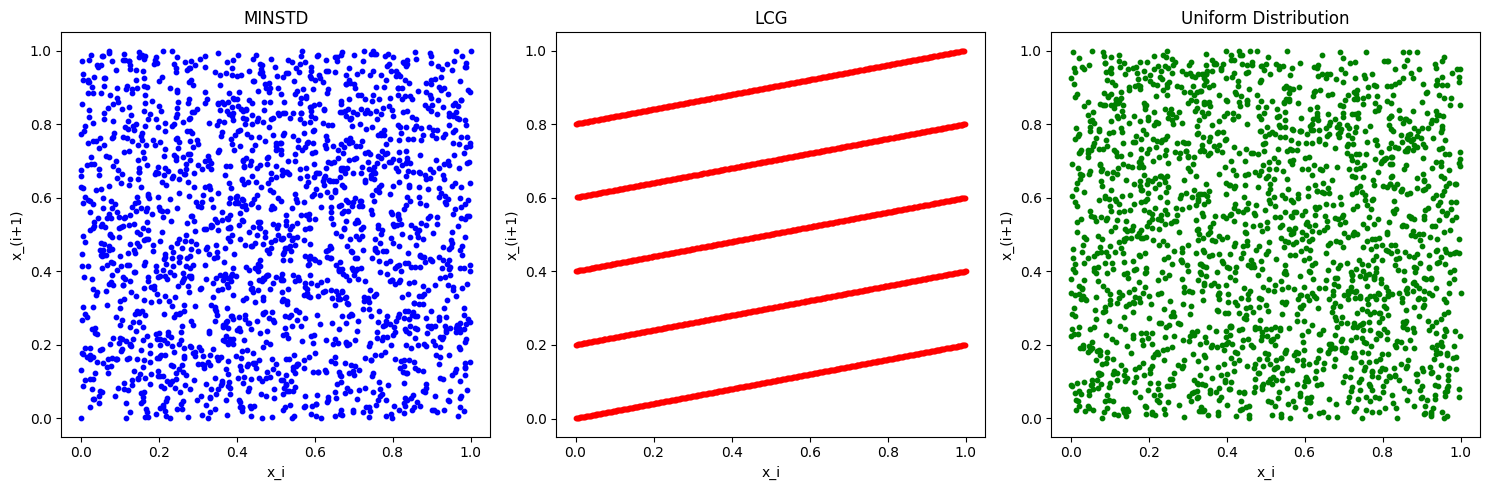

In [ ]:
#code for c) visual representation of the generated numbers

import matplotlib.pyplot as plt
import numpy as np

def my_lcg(n, seed, a, c, m):
    numbers_generated_lcg = np.array([])
    for i in range(n):
        seed = (a * seed + c) % m
        numbers_generated_lcg = np.append(numbers_generated_lcg, seed)
    return np.array(numbers_generated_lcg) / m


def minstd(n, seed, a, c, m):
    numbers_generated_minstd = np.array([])
    for i in range(n):
        seed = (a * seed + c) % m
        numbers_generated_minstd = np.append(numbers_generated_minstd, seed)
    return np.array(numbers_generated_minstd) / m

standard_data = minstd(2000, 1, 16807, 0, 2**31 - 1)
bad_data = my_lcg(2000, 1, 1229, 1, 2048)
accurate_data = np.random.uniform(0, 1, 2000)

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))
ax1.scatter(standard_data[:-1], standard_data[1:], s=10, color='blue')
ax1.set_title('MINSTD')
ax1.set_xlabel('x_i')
ax1.set_ylabel('x_(i+1)')

ax2.scatter(bad_data[:-1], bad_data[1:], s=10, color='red')
ax2.set_title('LCG')
ax2.set_xlabel('x_i')
ax2.set_ylabel('x_(i+1)')

ax3.scatter(accurate_data[:-1], accurate_data[1:], s=10, color='green')
ax3.set_title('Numpy Uniform Distribution')
ax3.set_xlabel('x_i')
ax3.set_ylabel('x_(i+1)')
plt.tight_layout()
plt.show()


Why is this lattice structure dangerous for scientific simulations (e.g., simulating a gas in
a 2D box)? Does the MINSTD generator show these lines? Does Numpy?

1) MINSTD Generator

- MINSTD generator its still a LCG so mathematically lines are there since we have ploted 2000 points its impossible to see them, a lower number of N points will allow to visualize them

2) Numpy generator

- numpy generator uses a mersenne twister algorithm which is far more advance than what I implemented and tested and it does not use the lattice flaws

3) Why is this lattice structure dangerous for scientific simulations (e.g., simulating a gas in a 2D box)? 

- I guess because of the physical accuracy of the simulation will suffer because the particle of gas will only appear on the Marsaglia Planes for example if we use a bad generator like the one is used and implemented, so we will have no points in between of the planes



### Deterministic Chaos (The Logistic Map)

- transition from pseudo random algorithms to deterministic chaos

Pseudo Random Number Generators (from before numpy Mersenne Twister algorithm, LCG) are trying to achieve true randomness by hiding the use of a mathematical formula.

Deterministic Chaos represents a system that is perfectly predictable in short term but for long term is impossible to predict. A chaotic system that outputs something completely random in a time series but its generated by a non random equation


### Logistic Map

- example of deterministic cahos = logistic map

- defined by a quadratic recurrence relation

$$x_{N+1} = 1 - r * x_{n}^{2}$$

- chaotic regime is define at a growth parameter of $r = 1.0$

##### Alternative Form

$$x_{n+1} = 4 * r * x_n * (1 - x_n) $$ also for $$r = 1$$


$\textbf{Sensitive Dependence on Initial Conditions}$

The defining feature of chaos is the "Butterfly Effect," mathematically known as sensitive dependence on initial conditions. If you start two identical chaotic systems with a microscopic difference such as an initial shift of $10^{-8}$ the trajectories will stay close together for a short time before diverging exponentially. After a certain number of steps, the two systems will bear zero resemblance to each other.

$\textbf{Return Maps}$

When plotted on a return map($x_n$ vs $x_{n+1}$):

$\textbf{Numpy}$: No relationships between steps, looks like and uniform accumulation of points

$\textbf{Bad LCG}$: contains the Marsaglia's planes, disconnected and values within a certain range

$\textbf{Deterministic chaos - Logistic Map}$: continuous, parabola


$\textbf{Probability Density and the Beta Distribution}$

Ideal random generators try to achieve a Uniform Distribution, where a histogram of the outputs is perfectly flat. The Logistic Map in the fully chaotic regime ($r=1.0$), however, spends most of its time near the edges of its bounds and less time in the middle. This creates a distinct, U-shaped probability density function. This specific U-shape is known as the Arcsine distribution, which is a special case of the broader family of Beta Distributions


#### Numerical Methods

$\textbf{Simulating Trajectory Divergence}$

To numerically demonstrate the Butterfly Effect, the Logistic Map is iterated for 100 steps under two separate initial conditions:Case A: $x_0 = 0.4$ Case B: $x_0 = 0.40000001$ By plotting both sequences on a single Time vs. Value graph, the exact time step $n$ where the macroscopic divergence occurs can be visually identified.

$\textbf{Phase Space Visualization}$ (Return Maps)

To compare the geometric structures of the systems, a sequence of $N=2000$ steps is generated using the Logistic Map with $r=1.0$. A scatter plot is created pairing the coordinates $(x_n, x_{n+1})$. This visual method immediately separates the continuous deterministic nature of the Logistic Map from the discrete lattice of the "Bad LCG" and the uncorrelated scatter of ideal noise.

$\textbf{Probability Density Calculation}$

To quantify the statistical distribution of the sequences, histograms are calculated for both the Numpy array and the 2000-step Logistic Map sequence. The numerical method involves sorting the generated values into equal-width bins and counting the frequency of occurrences. Comparing these plots will numerically confirm the flat shape of the uniform PRNG against the U-shaped (Beta-related) curve of the chaotic map.











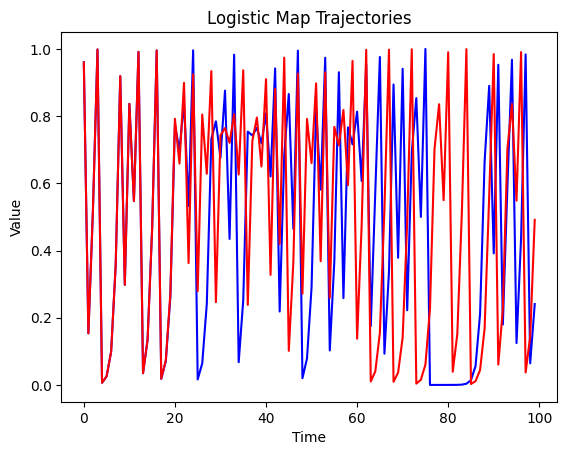

In [6]:
#code for d)

import numpy as np
import matplotlib.pyplot as plt

def logistic_map(steps, x, r):
    trajectory = np.array([])

    for i in range(steps):
        x = 4 * r * x * (1 - x)
        trajectory = np.append(trajectory, x)
    return trajectory


case_a = logistic_map(100, 0.4, 1)
case_b = logistic_map(100, 0.40000001, 1)


plt.plot(case_a, color='blue')
plt.plot(case_b, color='red')
plt.xlabel('Time')
plt.ylabel('Value')
plt.title('Logistic Map Trajectories')
plt.show()





Text(0, 0.5, 'x_(n+1)')

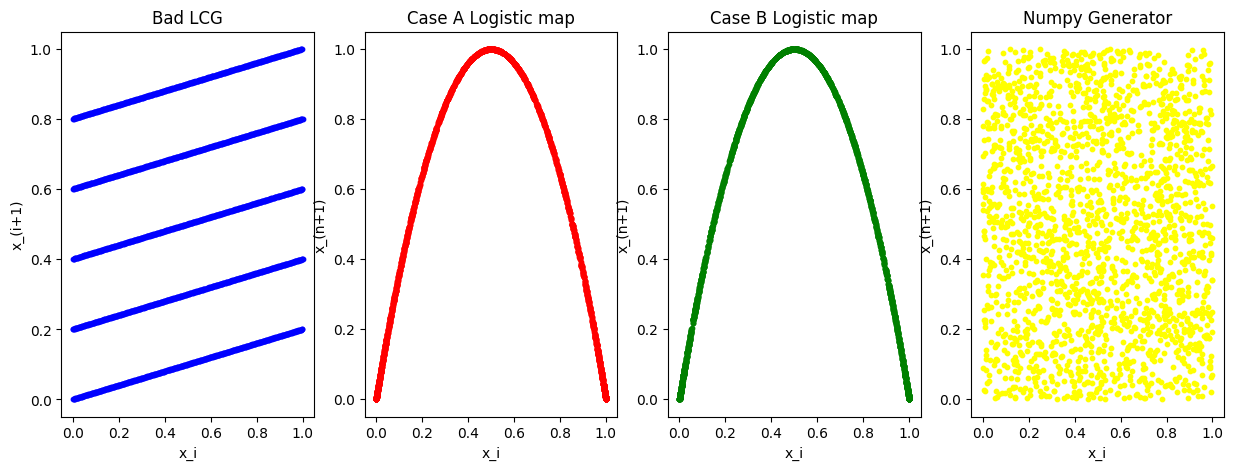

In [11]:
#code for e)

import numpy as np
import matplotlib.pyplot as plt

def bad_randomness(steps, x, a, r, m):
    num_generator = np.array([])

    for i in range(steps):
        x = (a * x + r) % m
        num_generator = np.append(num_generator, x)
    
    return np.array(num_generator) / m

def logistic_map(steps, x, r):
    trajectory = np.array([])

    for j in range(steps):
        x = 4 * r * x * (1 - x)
        trajectory = np.append(trajectory, x)

    return trajectory

bad_randomness_data = bad_randomness(2000, 1, 1229, 1, 2048)
logistic_map_data_case_a = logistic_map(2000, 0.4, 1)
logistic_map_data_case_b = logistic_map(2000,  0.40000001, 1)
numpy_generator_data = np.random.uniform(0, 1, 2000)


fig, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4, figsize=(15, 5))

ax1.scatter(bad_randomness_data[:-1], bad_randomness_data[1:], s=10, color='blue')
ax1.set_title('Bad LCG')
ax1.set_xlabel('x_i')
ax1.set_ylabel('x_(i+1)')

ax2.scatter(logistic_map_data_case_a[:-1], logistic_map_data_case_a[1:], s=10, color='red')
ax2.set_title("Case A Logistic map")
ax2.set_xlabel("x_i")
ax2.set_ylabel("x_(n+1)")

ax3.scatter(logistic_map_data_case_b[:-1], logistic_map_data_case_b[1:], s=10, color = 'green')
ax3.set_title('Case B Logistic map')
ax3.set_xlabel('x_i')
ax3.set_ylabel('x_(n+1)')

ax4.scatter(numpy_generator_data[:-1], numpy_generator_data[1:], s=10, color='yellow')
ax4.set_title('Numpy Generator')
ax4.set_xlabel('x_i')
ax4.set_ylabel('x_(n+1)')





##### f) Comparing the Return Maps

#### Geometrics

The bad LCG - map reveals the Marsaglia Planes, parallel diagonals separated by empty voids

The logistic map - continuous perfect parabola. This happens due to the purely quadratic functions that generate the sequence

$\textbf{Stochastic Noise}$ (Ideal Randomness):

A truly random sequence has zero correlation between one number and the next. If you plot it on a return map, it has absolutely no geometric structure. The system is fundamentally unpredictable.

$\textbf{Deterministic Chaos}$ (The Logistic Map):

Chaos is entirely different. The perfect parabola on the return map proves that the system is 100% deterministic, every value is perfectly predictable if you know the exact previous value and the mathematical rule. 


Text(0, 0.5, 'x_(n+1)')

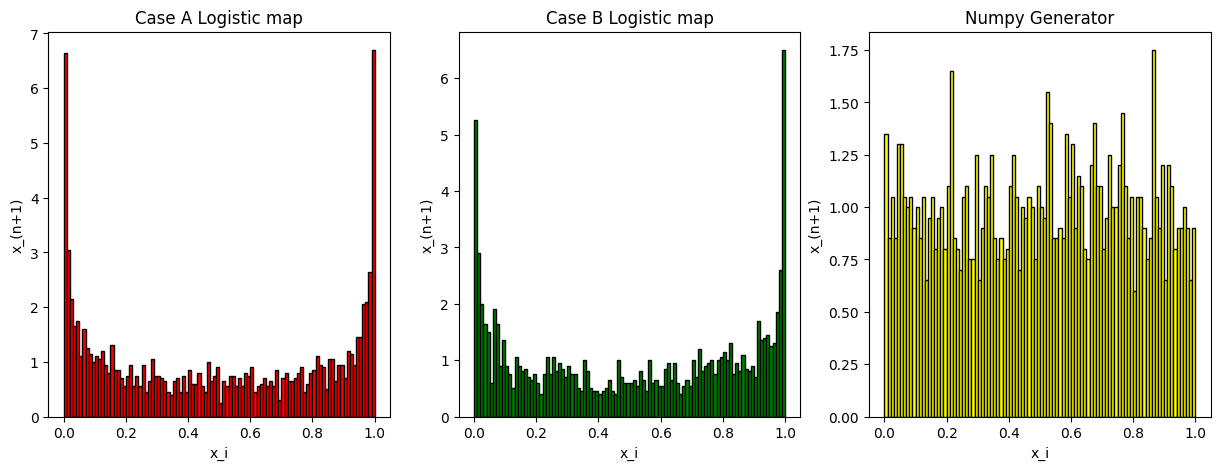

In [17]:
#code for g)

import numpy as np
import matplotlib.pyplot as plt

def logistic_map(steps, x, r):
    trajectory = np.array([])

    for j in range(steps):
        x = 4 * r * x * (1 - x)
        trajectory = np.append(trajectory, x)

    return trajectory


logistic_map_data_case_a = logistic_map(2000, 0.4, 1)
logistic_map_data_case_b = logistic_map(2000,  0.40000001, 1)
numpy_generator_data = np.random.uniform(0, 1, 2000)

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))

ax1.hist(logistic_map_data_case_a, bins=100, density=True, color='red', edgecolor='black')
ax1.set_title("Case A Logistic map")
ax1.set_xlabel("x_i")
ax1.set_ylabel("x_(n+1)")

ax2.hist(logistic_map_data_case_b, bins =100, density=True, color = 'green', edgecolor='black')
ax2.set_title('Case B Logistic map')
ax2.set_xlabel('x_i')
ax2.set_ylabel('x_(n+1)')

ax3.hist(numpy_generator_data, bins = 100, density = 100, color='yellow', edgecolor='black')
ax3.set_title('Numpy Generator')
ax3.set_xlabel('x_i')
ax3.set_ylabel('x_(n+1)')
